# CASE MORNING STAR
## Análise Exploratória de Dados dos Poços de Oleo e Gás

### Objetivo

Este projeto tem como objetivo realizar o tratamento e a análise exploratória da base de oleo e gás disponibilizada pela Morning Star.

A análise foi desenvolvida utilizando Python e bibliotecas de visualização de dados, buscando identificar padrões relacionados à distribuição geográfica, características operacionais e evolução temporal dos poços.

### Etapas Realizadas

#### Tratamento dos Dados

- Identificação e tratamento de valores nulos;
- Padronização da coluna de datas;
- Remoção do prefixo numérico dos identificadores dos poços;
- Criação da descrição completa para os tipos de localização (Terra e Mar);
- Validação da qualidade dos dados após os tratamentos.

#### Análise Exploratória

- Distribuição dos poços por localização;
- Distribuição por estado e bacia;
- Análise das situações operacionais;
- Comparação entre poços produzindo e injetando;
- Evolução histórica das conclusões de poços;
- Avaliação do comportamento recente da atividade no setor.

In [1]:
# 1. Importação das Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#2. Carregamento da Base de Dados
df = pd.read_excel('../data/[Case Técnico] - Tabela de Pocos.xlsx')

In [3]:
# 3. Conhecendo a Base de Dados, suas colunas, tipos de dados.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30044 entries, 0 to 30043
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   POCO          30044 non-null  str           
 1   OPERADOR      27104 non-null  str           
 2   ESTADO        30044 non-null  str           
 3   BACIA         30044 non-null  str           
 4   CAMPO         25533 non-null  str           
 5   TERRA_MAR     30044 non-null  str           
 6   CATEGORIA     30044 non-null  str           
 7   SITUACAO      29410 non-null  str           
 8   CONCLUSAO     29831 non-null  datetime64[us]
 9   TITULARIDADE  30044 non-null  str           
dtypes: datetime64[us](1), str(9)
memory usage: 2.3 MB


In [4]:
# Primeiros 10 registros para analisar os dados.
df.head(10)

,POCO,OPERADOR,ESTADO,BACIA,CAMPO,TERRA_MAR,CATEGORIA,SITUACAO,CONCLUSAO,TITULARIDADE
0,7-TBAZ-1HP-RJS,Dommo Energia,RJ,Campos,TUBARÃO AZUL,M,Desenvolvimento,ABANDONADO PERMANENTEMENTE,2013-01-12,Público
1,3-OGX-50D-RJS,Dommo Energia,RJ,Campos,TUBARÃO AZUL,M,Extensão,ABANDONADO PERMANENTEMENTE,2011-07-24,Público
2,3-OGX-53D-RJS,Dommo Energia,RJ,Campos,TUBARÃO AZUL,M,Extensão,ABANDONADO PERMANENTEMENTE,2011-08-22,Público
3,3-OGX-21D-RJS,Dommo Energia,RJ,Campos,NaN,M,Extensão,ABANDONADO PERMANENTEMENTE,2010-11-26,Público
4,9-OGX-68HP-RJS,Dommo Energia,RJ,Campos,TUBARÃO AZUL,M,Especial,ABANDONADO PERMANENTEMENTE,2012-03-26,Público
5,1-OGX-3-RJS,Dommo Energia,RJ,Campos,NaN,M,Pioneiro,ABANDONADO PERMANENTEMENTE,2010-02-25,Público
6,9-OGX-55HP-RJS,Dommo Energia,RJ,Campos,TUBARÃO TIGRE,M,Especial,ABANDONADO PERMANENTEMENTE,2011-10-18,Público
7,9-OGX-60HP-RJS,Dommo Energia,RJ,Campos,TUBARÃO AZUL,M,Especial,ABANDONADO PERMANENTEMENTE,2012-01-09,Público
8,3-OGX-65D-RJS,Dommo Energia,RJ,Campos,TUBARÃO AZUL,M,Extensão,ABANDONADO PERMANENTEMENTE,2011-11-23,Público
9,4-BRSA-1223-SES,Petrobras,SE,Sergipe,PIRANEMA SUL,M,Pioneiro Adjacente,ARRASADO,2014-04-13,Público


In [5]:
# Análise de dados estatísticos
df.describe(include='all')

,POCO,OPERADOR,ESTADO,BACIA,CAMPO,TERRA_MAR,CATEGORIA,SITUACAO,CONCLUSAO,TITULARIDADE
count,30044,27104,30044,30044,25533,30044,30044,29410,29831,30044
unique,30044,94,24,37,557,2,9,25,NaN,2
top,7-TBAZ-1HP-RJS,Petrobras,RN,Potiguar,CARMÓPOLIS,T,Desenvolvimento,PRODUZINDO,NaN,Público
freq,1,23471,8280,9324,1986,23241,18592,7260,NaN,29487
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1991-07-18 07:09:14.041098,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1922-06-30 00:00:00,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1982-02-22 00:00:00,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1989-01-09 00:00:00,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-11-13 00:00:00,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-01 00:00:00,NaN


In [6]:
#Verificação inicial de valores nulos
df.isnull().sum().sort_values(ascending=False)

CAMPO           4511
OPERADOR        2940
SITUACAO         634
CONCLUSAO        213
POCO               0
ESTADO             0
TERRA_MAR          0
BACIA              0
CATEGORIA          0
TITULARIDADE       0
dtype: int64

## Diagnóstico Inicial da Base

A etapa inicial teve como objetivo compreender a estrutura da base de dados e identificar possíveis inconsistências.

## Tratamento das Datas

Foram identificados 213 registros sem data de conclusão.

Como não havia informações suficientes para inferir datas válidas, esses registros foram mantidos como ausentes (NaT).

Essa abordagem evita a criação de informações artificiais e garante maior confiabilidade às análises temporais.

Os registros permanecem disponíveis para as demais análises da base, sendo excluídos apenas dos indicadores dependentes de data.

In [7]:

#4.1 Padronização da Data de Conclusão
df['CONCLUSAO'] = pd.to_datetime( df['CONCLUSAO'], errors='coerce' )

In [8]:
#Substituição dos valores nulos em campos textuais por string vazia.

colunas_texto = [ 'POCO', 'OPERADOR', 'ESTADO', 'BACIA', 'CAMPO', 'TERRA_MAR', 'CATEGORIA', 'SITUACAO', 'TITULARIDADE' ] 
df[colunas_texto] = df[colunas_texto].fillna('')

In [9]:
# Reanálise dos dados após o tratamento
df.head(5)

,POCO,OPERADOR,ESTADO,BACIA,CAMPO,TERRA_MAR,CATEGORIA,SITUACAO,CONCLUSAO,TITULARIDADE
0,7-TBAZ-1HP-RJS,Dommo Energia,RJ,Campos,TUBARÃO AZUL,M,Desenvolvimento,ABANDONADO PERMANENTEMENTE,2013-01-12,Público
1,3-OGX-50D-RJS,Dommo Energia,RJ,Campos,TUBARÃO AZUL,M,Extensão,ABANDONADO PERMANENTEMENTE,2011-07-24,Público
2,3-OGX-53D-RJS,Dommo Energia,RJ,Campos,TUBARÃO AZUL,M,Extensão,ABANDONADO PERMANENTEMENTE,2011-08-22,Público
3,3-OGX-21D-RJS,Dommo Energia,RJ,Campos,,M,Extensão,ABANDONADO PERMANENTEMENTE,2010-11-26,Público
4,9-OGX-68HP-RJS,Dommo Energia,RJ,Campos,TUBARÃO AZUL,M,Especial,ABANDONADO PERMANENTEMENTE,2012-03-26,Público


In [10]:
#Remoção do primeiro número do identificador dos poços
df['POCO'] = df['POCO'].str.split('-', n=1).str[1]


In [11]:
# Verificação do resultado da remoção do número do identificador dos poços
df['POCO']

0        TBAZ-1HP-RJS
1         OGX-50D-RJS
2         OGX-53D-RJS
3         OGX-21D-RJS
4        OGX-68HP-RJS
             ...     
30039      ET-1438-RN
30040       MAG-49-RN
30041      CAM-214-RN
30042      CAM-331-RN
30043      CAM-342-RN
Name: POCO, Length: 30044, dtype: object

In [12]:
# Criação de uma nova coluna com a descrição de Terra ou Mar
df['TERRA_MAR_DESC'] = df['TERRA_MAR'].map({ 'T': 'Terra', 'M': 'Mar' })


In [13]:
# Criação da coluna ANO para simplificar as análises temporais
df['ANO'] = df['CONCLUSAO'].dt.year.astype('Int64')

In [14]:
#Validação dos Dados Tratados
df.isnull().sum()

POCO                0
OPERADOR            0
ESTADO              0
BACIA               0
CAMPO               0
TERRA_MAR           0
CATEGORIA           0
SITUACAO            0
CONCLUSAO         213
TITULARIDADE        0
TERRA_MAR_DESC      0
ANO               213
dtype: int64

In [15]:
# Desconsiderando os registros com data de conclusão nula para as análises
df_data = df.dropna(subset=['CONCLUSAO']).copy()

# Análise Exploratória dos Dados

TERRA_MAR_DESC
Terra    23085
Mar       6746
Name: count, dtype: int64


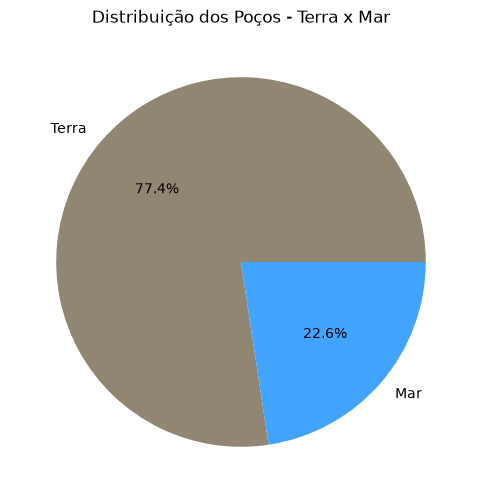

In [16]:
# Ditribuição dos Poços - Terra x Mar
contagem = df_data['TERRA_MAR_DESC'].value_counts().reindex(['Terra', 'Mar'])
plt.figure(figsize=(6,6))

df_data['TERRA_MAR_DESC'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#908672', '#41A4FF']
)

plt.title('Distribuição dos Poços - Terra x Mar')
plt.ylabel('')
print(contagem)


Insight

Observa-se predominância de poços terrestres na base analisada.


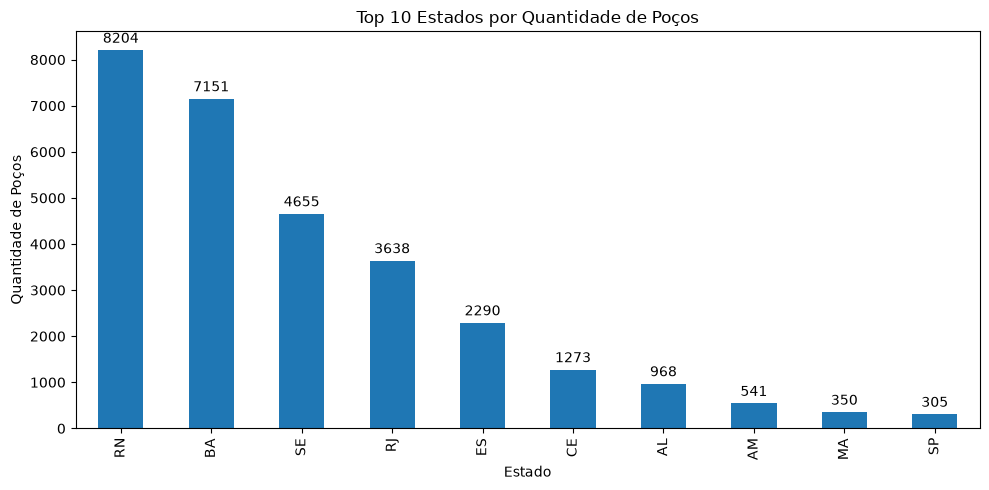

In [17]:
# Top 10 Estados por Quantidade de Poços
top_estados = df_data['ESTADO'].value_counts().head(10)

plt.figure(figsize=(10,5))

ax = top_estados.plot(kind='bar')

plt.title('Top 10 Estados por Quantidade de Poços')
plt.xlabel('Estado')
plt.ylabel('Quantidade de Poços')

ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()

Insight

A atividade encontra-se concentrada em poucos estados, sugerindo regiões estratégicas para exploração e produção de petróleo e gás.

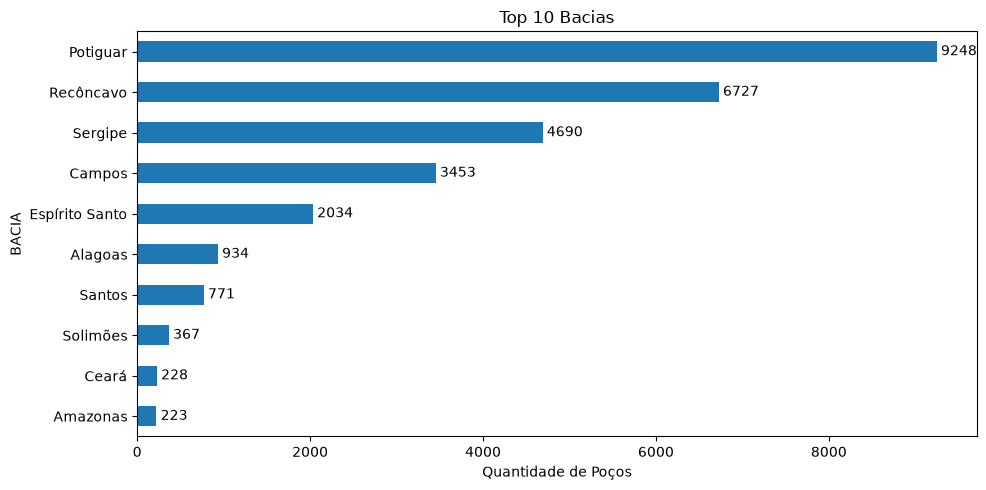

In [18]:
# Top 10 Bacias por Quantidade de Poços
top_bacias = df_data['BACIA'].value_counts().head(10)

plt.figure(figsize=(10,5))

ax = top_bacias.sort_values().plot(kind='barh')

plt.title('Top 10 Bacias')
plt.xlabel('Quantidade de Poços')

ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()

Insight

As principais bacias concentram parcela significativa dos poços, evidenciando sua importância para o desenvolvimento da indústria.

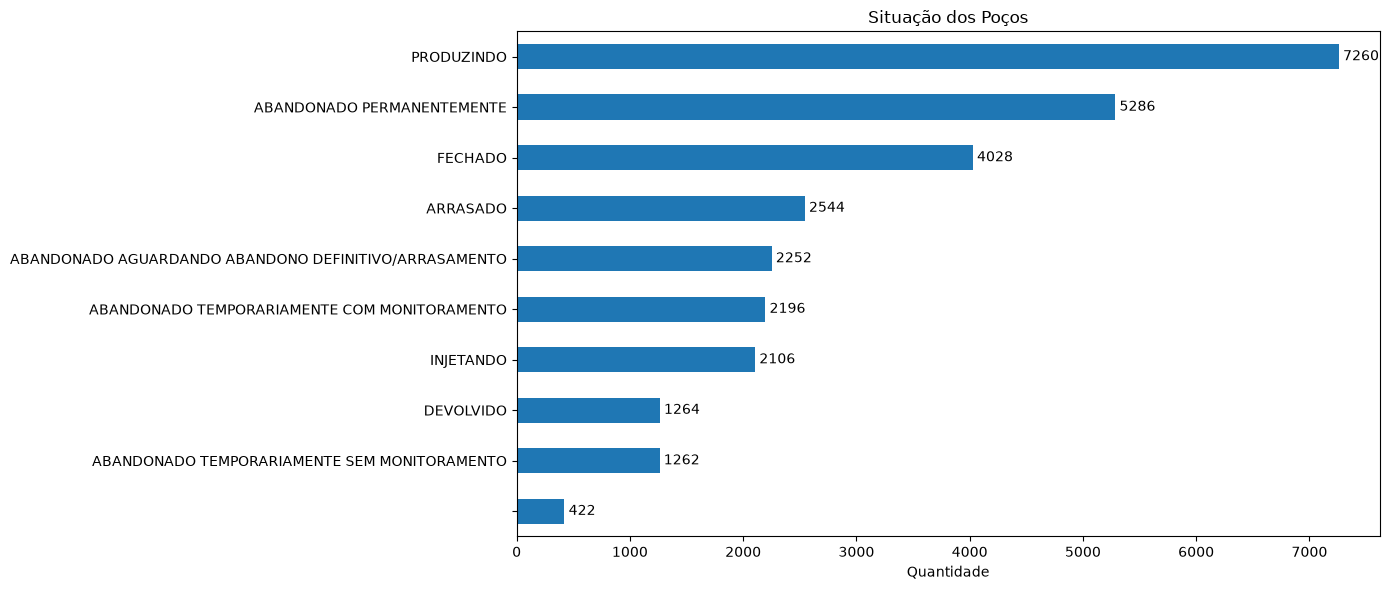

In [19]:
# Situação dos Poços - Top 10 Situações
plt.figure(figsize=(14,6))

ax = (
    df_data['SITUACAO']
    .value_counts()
    .head(10)
    .sort_values()
    .plot(kind='barh')
)

plt.title('Situação dos Poços')
plt.xlabel('Quantidade')
plt.ylabel('')

ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()

Insight

A distribuição das situações operacionais permite compreender o estágio atual dos ativos presentes na base.

A presença de poços produzindo, injetando, abandonados e fechados demonstra diferentes fases do ciclo de vida dos campos.

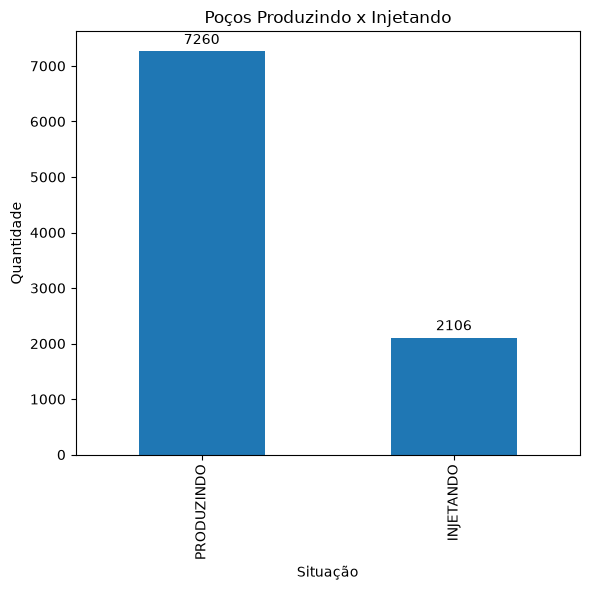

In [24]:
# Poços Produzindo x Injetando
operacao = df_data[
    df_data['SITUACAO'].isin([
        'PRODUZINDO',
        'INJETANDO'
    ])
].copy()

plt.figure(figsize=(6,6))

ax = operacao['SITUACAO'].value_counts().plot(
    kind='bar'
)

plt.title('Poços Produzindo x Injetando')
plt.xlabel('Situação')
plt.ylabel('Quantidade')

ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()

Insight

A relação entre poços produtores e injetores evidencia estratégias de manutenção da pressão dos reservatórios e otimização da recuperação de petróleo.

Esse indicador é um dos principais pontos de análise para a gestão operacional dos campos.

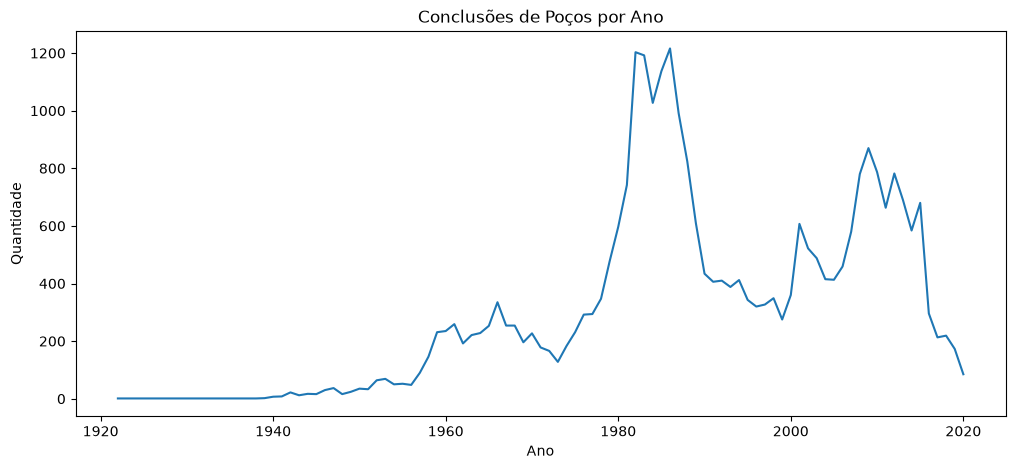

In [21]:
# Análise de Poços por Ano
evolucao = df_data.groupby('ANO').size() 
plt.figure(figsize=(12,5)) 
evolucao.plot() 
plt.title('Conclusões de Poços por Ano') 
plt.xlabel('Ano') 
plt.ylabel('Quantidade') 
plt.show()

Insight

A série histórica permite identificar períodos de crescimento e retração das atividades de perfuração e conclusão de poços.

Essas variações podem estar associadas a fatores econômicos, regulatórios e tecnológicos do setor.

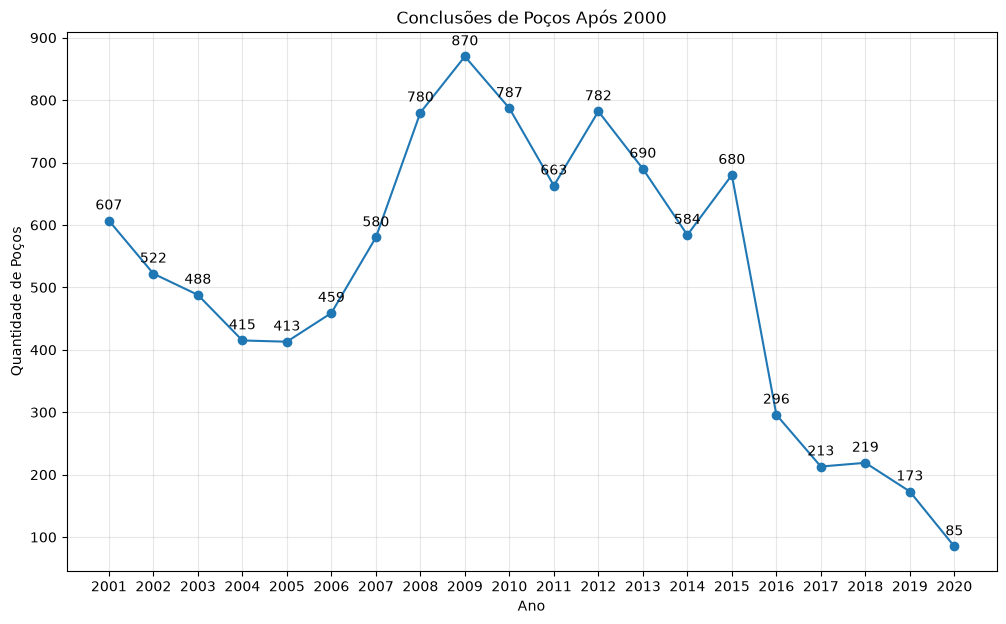

In [22]:
# Análise de Conclusões de Poços Após 2000
grafico = (
    df_data[df_data['ANO'] > 2000]
    .groupby('ANO')
    .size()
)

plt.figure(figsize=(12,7))

plt.plot(
    grafico.index,
    grafico.values,
    marker='o'
)

for x, y in zip(grafico.index, grafico.values):
    plt.annotate(
        str(y),
        (x, y),
        textcoords='offset points',
        xytext=(0,8),
        ha='center'
    )

plt.xticks(grafico.index)

plt.title('Conclusões de Poços Após 2000')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Poços')

plt.grid(True, alpha=0.3)

plt.show()

Insight

A análise das conclusões após o ano 2000 permite observar o comportamento mais recente da indústria e possíveis tendências de crescimento ou desaceleração.

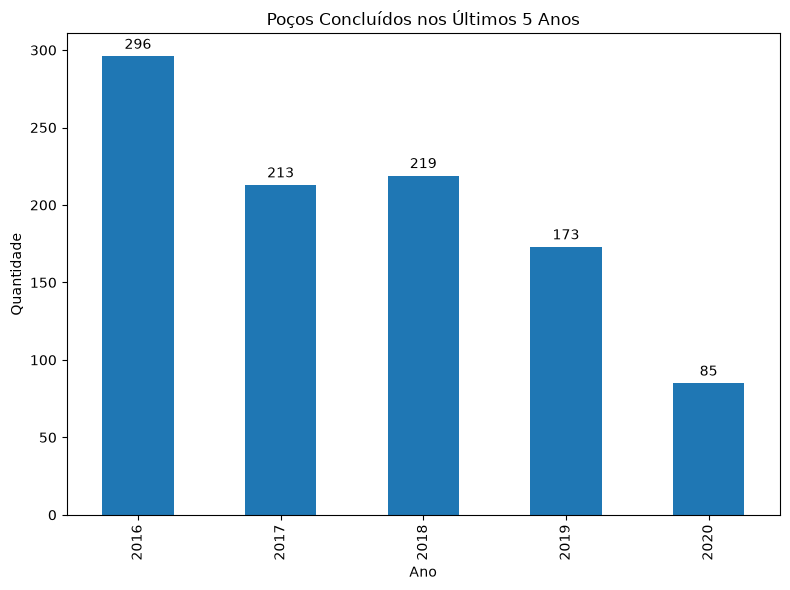

In [23]:
# Poços Concluídos nos Últimos 5 Anos
ultimo_ano = df_data['ANO'].max()

ultimos_5 = df_data[
    df_data['ANO'] > ultimo_ano - 5
]

grafico = ultimos_5.groupby('ANO').size()

plt.figure(figsize=(8,6))

ax = grafico.plot(kind='bar')

plt.title('Poços Concluídos nos Últimos 5 Anos')
plt.xlabel('Ano')
plt.ylabel('Quantidade')

ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()


Insight

A análise das conclusões após o ano 2000 permite observar o comportamento mais recente da indústria e possíveis tendências de crescimento ou desaceleração.